## Lab 5: Model Evaluation in Classification with Breast Cancer Dataset

In this lab you will be focusing on model evaluation using a larger dataset, specifically the famous Breast Cancer Wisconsin (Diagnostic) dataset, found on scikit-learn dataset reporistory. This dataset contains features computed from a digitized image of a fine needle aspirate (FNA) of a breast mass, and the target variable indicates whether the mass is benign or malignant.

### Objective:

In this lab, you will evaluate the performance of different classification models using various evaluation metrics and techniques on the Breast Cancer Wisconsin (Diagnostic) dataset. The classification models that you will look for are: Support Vector Machines (SVM), Random Forest and Gradient Boosting. The tasks involved are:

#### 1) Load the Breast Cancer dataset

Load the nessecary python libabries and the breast cancer dataset (the name of the dataset from scikit-learn is: <code>load_breast_cancer</code>). Select also data and train targets.


In [16]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Step 1: Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

#### 2) Preprocess the data (if necessary).

Perform an initial analysis of the daatset! If the data quaility is fine (no missing data etc.) You cna skip this step. 

#### 3) Split the data into training and testing sets.

Try the split ratio of 80/20. Check and printout the output shapes after the split. 

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(455, 30) (114, 30) (455,) (114,)


#### 4) Train multiple classification models

The models that should be trained are: 

<ul>
<li>Support Vector Machine (SVM)</li>
<li>Random Forest</li>
<li>Gradient Boosting</li>
</ul>

Consider defining and using a pipeline of models and train them through the pipeline. 

In [7]:
models = {
    'Support Vector Machine': SVC(probability=True),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)

#### 5) Evaluate the models using the following evaluation metrics:
<ul>
<li>Accuracy</li>
<li>Precision</li>
<li>Recall</li>
<li>F1 Score</li>
<li>ROC-AUC Score</li>
</ul>

In [8]:
metrics = {
    'Accuracy': accuracy_score,
    'Precision': precision_score,
    'Recall': recall_score,
    'F1 Score': f1_score,
    'ROC-AUC Score': roc_auc_score
}

for name, model in models.items():
    print(f"Evaluation metrics for {name}:")
    y_pred = model.predict(X_test)
    for metric_name, metric_func in metrics.items():
        score = metric_func(y_test, y_pred)
        print(f"{metric_name}: {score}")
    print()

Evaluation metrics for Support Vector Machine:
Accuracy: 0.9473684210526315
Precision: 0.922077922077922
Recall: 1.0
F1 Score: 0.9594594594594594
ROC-AUC Score: 0.9302325581395349

Evaluation metrics for Random Forest:
Accuracy: 0.9649122807017544
Precision: 0.958904109589041
Recall: 0.9859154929577465
F1 Score: 0.9722222222222222
ROC-AUC Score: 0.9580740255486406

Evaluation metrics for Gradient Boosting:
Accuracy: 0.956140350877193
Precision: 0.9583333333333334
Recall: 0.971830985915493
F1 Score: 0.965034965034965
ROC-AUC Score: 0.9510317720275139



#### 6) Compare the model performance metrics

Which of the models perform better? Which of these metrics would you trust the most? Why?

#### 7) Plot the ROC curves for each model

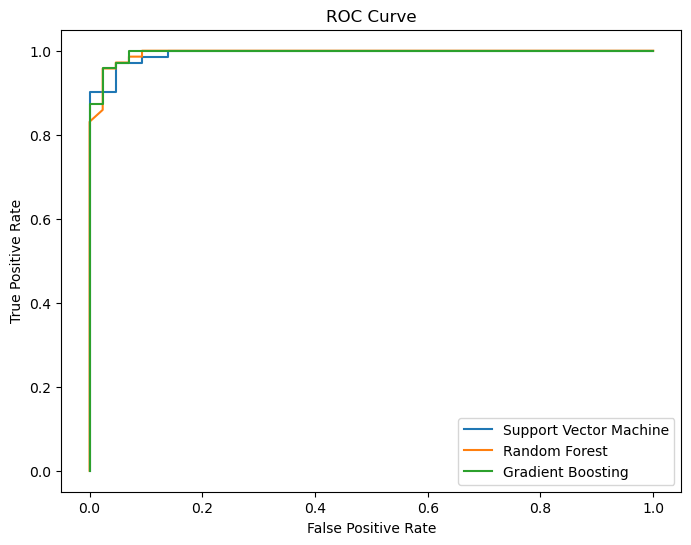

In [9]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=name)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

#### 8) Evaluate with Cross-validation

Repeat steps 4) - 7) using 10-fold cross validation during model training instead of simple holdout method. What is the difference? Why is that?

In [19]:
# Step 4: Initialize multiple classification models
models = {
    'Support Vector Machine': SVC(probability=True),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

# Step 5: Evaluate the models using 10-fold cross-validation
metrics = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'Recall': 'recall',
    'F1 Score': 'f1',
    'ROC-AUC Score': 'roc_auc'
}

for name, model in models.items():
    print(f"Evaluation metrics for {name}:")
    cv_results = cross_validate(model, X, y, cv=10, scoring=metrics)
    for metric_name, scores in cv_results.items():
        print(f"{metric_name}: {np.mean(scores):.2f} (+/- {np.std(scores):.2f})")
    print()

Evaluation metrics for Support Vector Machine:
fit_time: 0.01 (+/- 0.00)
score_time: 0.00 (+/- 0.00)
test_Accuracy: 0.91 (+/- 0.03)
test_Precision: 0.90 (+/- 0.04)
test_Recall: 0.98 (+/- 0.02)
test_F1 Score: 0.93 (+/- 0.02)
test_ROC-AUC Score: 0.98 (+/- 0.01)

Evaluation metrics for Random Forest:
fit_time: 0.09 (+/- 0.00)
score_time: 0.01 (+/- 0.00)
test_Accuracy: 0.96 (+/- 0.04)
test_Precision: 0.96 (+/- 0.04)
test_Recall: 0.97 (+/- 0.03)
test_F1 Score: 0.97 (+/- 0.03)
test_ROC-AUC Score: 0.99 (+/- 0.01)

Evaluation metrics for Gradient Boosting:
fit_time: 0.33 (+/- 0.00)
score_time: 0.00 (+/- 0.00)
test_Accuracy: 0.96 (+/- 0.02)
test_Precision: 0.96 (+/- 0.03)
test_Recall: 0.98 (+/- 0.02)
test_F1 Score: 0.97 (+/- 0.02)
test_ROC-AUC Score: 0.99 (+/- 0.01)



#### Bonus Task

Try other validation methods such as Bootstrapping. See how you cna implemnt that in scikit-learn. 